In [1]:
! pwd

/media/ronit/SharedVolume/lwm_project/LWM/lwm_physics


In [2]:
! which python

/home/ronit/anaconda3/envs/lwm_cuda/bin/python


In [3]:
import os
import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import subprocess
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, random_split, TensorDataset
import csv, json, time
from sklearn.metrics import f1_score
from tqdm import tqdm  # Progress bar
import torch.optim as optim
import math
plt.show = lambda: None


from lwm.input_preprocess import create_labels, DeepMIMO_data_gen, deepmimo_data_cleaning
from lwm_ca.torch_pipeline import LWMWithPrepatchCA, ensure_ri_channels, add_complex_noise_ri, channels_to_patches
from lwm_physics.lwm_physics_model import lwm_physics

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using",device)

/home/ronit/anaconda3/envs/lwm_cuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda


In [ ]:
###################helper funtions#################################
def stack_cleaned_channels(deepmimo_data):
    cleaned = [deepmimo_data_cleaning(dm) for dm in deepmimo_data]
    return np.vstack(cleaned)

def channels_to_ri(channels):
    real = channels.real.astype(np.float32)
    imag = channels.imag.astype(np.float32)
    return np.stack([real, imag], axis=1)

def load_state_dict_flexible(model, ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and any(k.startswith("_orig_mod.") for k in state.keys()):
        state = {k.replace("_orig_mod.", "", 1): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)
    return model

##########build data set set using lwm_physics########################################
def build_dataset(
    channels_ri,
    input_types,
    model_ckpt,
    snr_db,
    device,
    batch_size=64,
):
    datasets = {}
    need_raw = "raw" in input_types
    need_embeddings = any(t in {"cls_emb", "channel_emb"} for t in input_types)

    tensor = torch.from_numpy(channels_ri)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(tensor), batch_size=batch_size, shuffle=False
    )

    model = lwm_physics().to(device)
    model = load_state_dict_flexible(model, model_ckpt, device)
    model.eval()

    raw_batches = []
    embedding_batches = []
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            if need_raw:
                channels = ensure_ri_channels(batch)
                if snr_db is not None:
                    channels = add_complex_noise_ri(channels, snr_db)
                ca_out = model.coordatt(channels)
                patch_batch = channels_to_patches(ca_out, patch_size=model.patch_size)
                raw_batches.append(patch_batch.cpu())
            if need_embeddings:
                _, _, output = model(batch)
                embedding_batches.append(output.cpu())

    if need_raw:
        datasets["raw"] = torch.cat(raw_batches, dim=0)
    if need_embeddings:
        embeddings = torch.cat(embedding_batches, dim=0)
        if "cls_emb" in input_types:
            datasets["cls_emb"] = embeddings[:, 0]
        if "channel_emb" in input_types:
            datasets["channel_emb"] = embeddings[:, 1:]
    return datasets





In [10]:
# Define scenario names and select one (or more).
scenario_names = np.array([
    "city_0_newyork", "city_1_losangeles", "city_2_chicago", "city_3_houston",
    "city_4_phoenix", "city_5_philadelphia", "city_6_miami", "city_7_sandiego",
    "city_8_dallas", "city_9_sanfrancisco", "city_10_austin", "city_11_santaclara",
    "city_12_fortworth", "city_13_columbus", "city_15_indianapolis", "city_17_seattle",
    "city_18_denver", "city_19_oklahoma", "O1_3p5B", "O1_3p5"])
#################################################### Select the first scenario (index 0) – adjust as needed##################################################
scenario_idxs = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])[0:2]
selected_scenario_names = scenario_names[scenario_idxs]
print("selected scenarios: ")
for i in selected_scenario_names: print(i, end=", ")

selected scenarios: 
city_0_newyork, city_1_losangeles, 

In [11]:
#######################################################SELECT INPUT############################################################################################
input_types = ['cls_emb', 'channel_emb']
selected_input_type = input_types[0] # choose one: 'cls_emb', 'channel_emb', or 'raw'
deepmimo_data = [DeepMIMO_data_gen(scenario_name) for scenario_name in selected_scenario_names]
cleaned_channels = stack_cleaned_channels(deepmimo_data)
print(cleaned_channels.shape)
print("\nusing",selected_input_type,"as input")


Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 5148/5148 [00:00<00:00, 32948.91it/s]



Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 4617/4617 [00:00<00:00, 49858.14it/s]

(2023, 1, 32, 32)

using cls_emb as input



Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5148/5148 [00:00<00:00, 104747.72it/s]



Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 4617/4617 [00:00<00:00, 146796.51it/s]


using cls_emb for Beam Prediction task


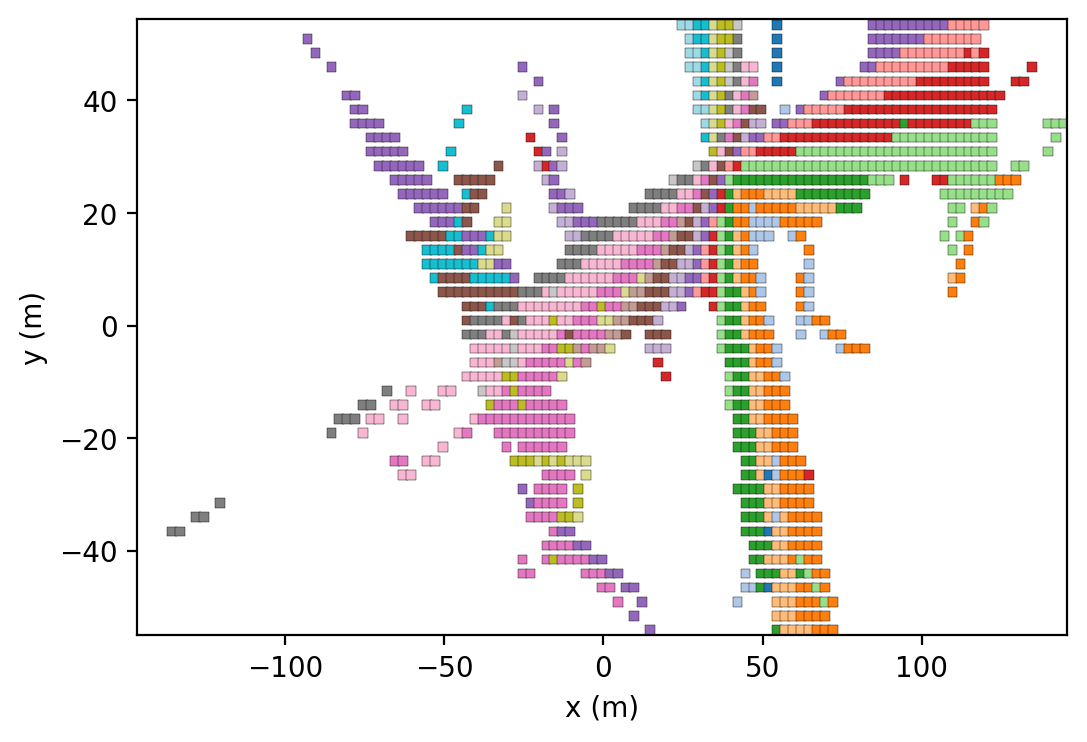

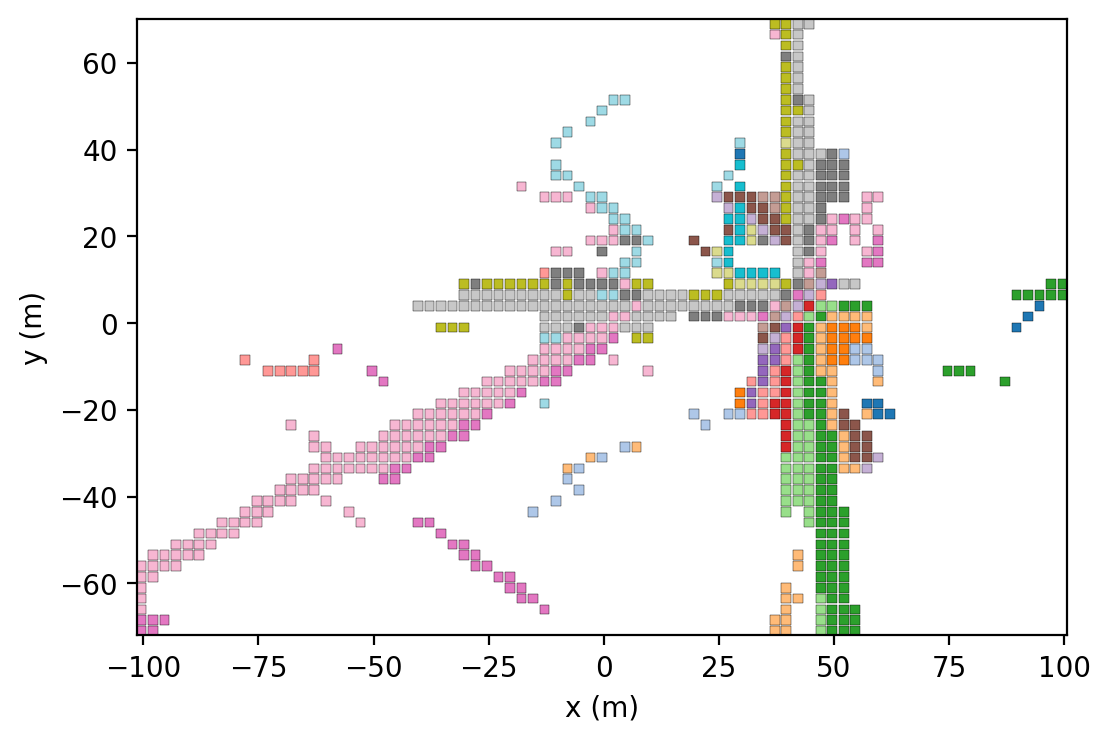

In [12]:
################Select Tasks#################################and change batch size##################
#generate targets/lables
tasks = ['LoS/NLoS Classification', 'Beam Prediction']
task = tasks[1] # Choose 0 for LoS/NLoS labels or 1 for beam prediction labels.
labels = create_labels(task, selected_scenario_names, n_beams=64)
print("using",selected_input_type,"for",task,"task")

In [13]:
channels_ri = channels_to_ri(cleaned_channels)
ca_ckpt = "model_weights_physics_ddp.pth"
snr_db = None
batch_size = 32 #earlier 32
datasets_physics = build_dataset(
                channels_ri,
                input_types,                            #cls_emb / channel_emb
                ca_ckpt, #path to weights
                snr_db,                            #snr_db
                device,
                batch_size,
            )
# print(datasets_ca)
dataset = datasets_physics[selected_input_type]
print(selected_input_type,'\n',"data: ",
type(dataset),
len(dataset),
dataset.shape
)
print("labels: ",
    type(labels),len(labels)
)

/tmp/ipykernel_78615/3855771921.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


cls_emb 
 data:  <class 'torch.Tensor'> 2023 torch.Size([2023, 64])
labels:  <class 'torch.Tensor'> 2023


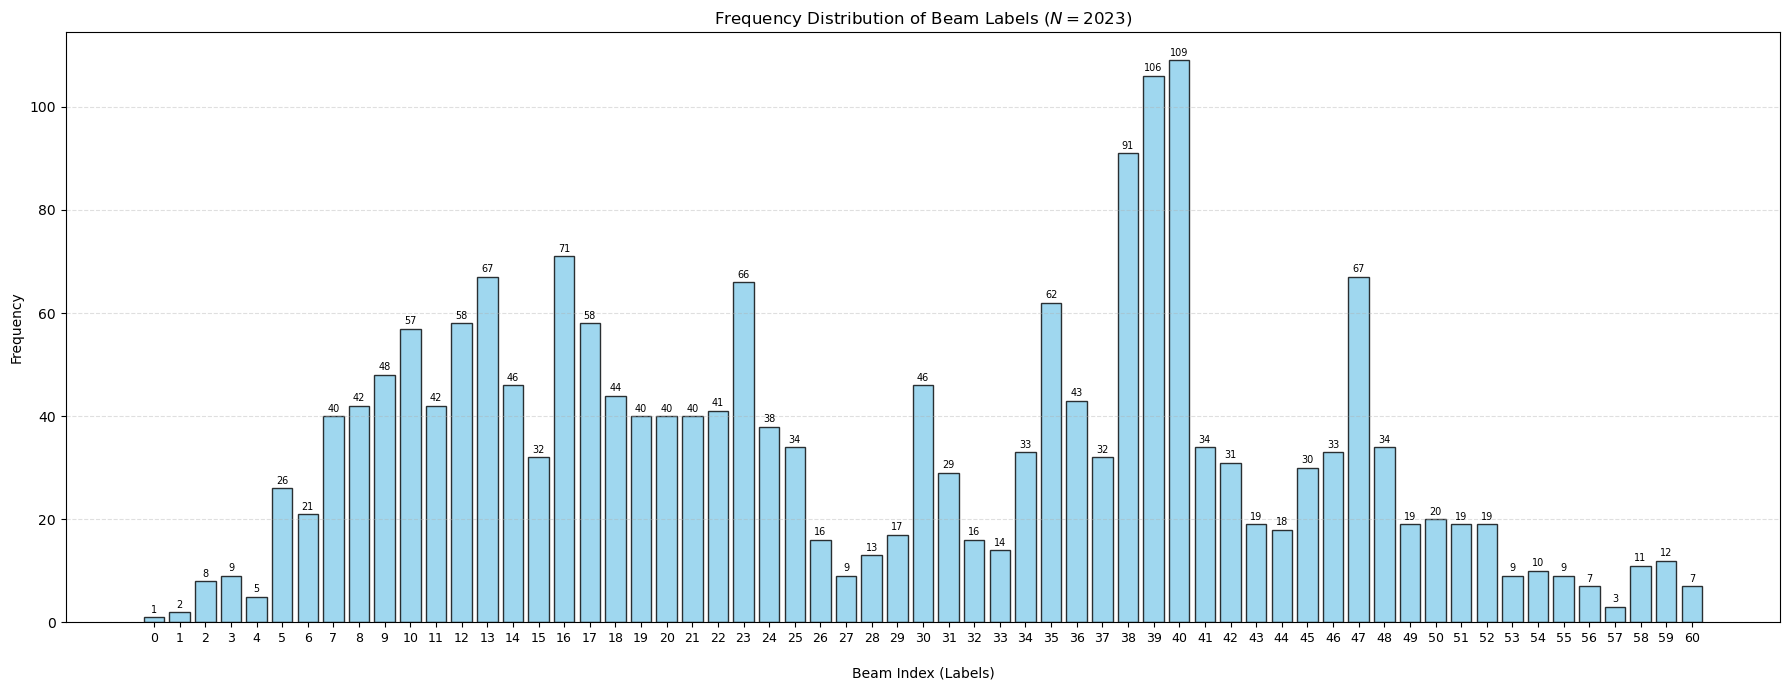

In [14]:
unique_labels, counts = torch.unique(labels, return_counts=True)
x_values = unique_labels.cpu().numpy()
y_values = counts.cpu().numpy()

# 2. Increase figure width (e.g., to 16 or 18) to create more horizontal space
plt.figure(figsize=(18, 7))

# 3. Create bars
bars = plt.bar(x_values, y_values, color='skyblue', edgecolor='black', alpha=0.8)

# Adding some padding with 'labelpad' if needed
plt.xticks(x_values, rotation=0, fontsize=9)

# 5. Annotate each bar with its frequency count
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval),
             va='bottom', ha='center', fontsize=7, rotation=0)

# 6. Add labels and title
plt.xlabel('Beam Index (Labels)', labelpad=15)
plt.ylabel('Frequency')
plt.title(f'Frequency Distribution of Beam Labels ($N = {len(labels)}$)')

# 7. Use tight_layout to ensure no labels are cut off at the edges
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

In [15]:
#function to combine data and labels and split in the given train ratio ratio
def get_data_loaders(data_tensor, labels_tensor, batch_size=32, train_ratio=0.8):
    dataset = TensorDataset(data_tensor, labels_tensor)
    N = len(dataset)

    train_size = int(train_ratio * N)
    remaining = N - train_size
    val_size = remaining // 2
    test_size = remaining - val_size

    train_dataset, val_dataset, test_dataset = random_split(dataset,[train_size, val_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [17]:
# Mapping for beam prediction input types.
mapping = {
    'cls_emb': {'input_channels': 1, 'sequence_length': 64},
    'channel_emb': {'input_channels': 64, 'sequence_length': 128},
    'raw': {'input_channels': 16, 'sequence_length': 128}
}
input_type = selected_input_type  # use the same type as for data generation
params = mapping.get(input_type, mapping[selected_input_type]) #change if chosen anything else
n_beams = 64  # adjust as needed
initial_lr = 0.001
num_classes = n_beams + 1  # as defined in your code
print(selected_input_type)

cls_emb


In [18]:
# ----------------------------------
# 1. SE LAYER
# ----------------------------------
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)


# ----------------------------------
# 2. RESIDUAL BLOCK (WITH OPTIONAL SE)
# ----------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, use_se=False):
        super().__init__()

        self.conv1 = nn.Conv1d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_c)

        self.conv2 = nn.Conv1d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_c)

        self.relu = nn.ReLU(inplace=True)
        self.se = SELayer(out_c) if use_se else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm1d(out_c)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Apply SE attention (if enabled)
        out = self.se(out)

        out += identity
        out = self.relu(out)

        return out


# ----------------------------------
# 3. MAIN MODEL
# ----------------------------------
class SEResNet1D(nn.Module):
    def __init__(self, input_channels, sequence_length, num_classes):
        super().__init__()

        # No early downsampling
        self.conv1 = nn.Conv1d(
            input_channels, 64,
            kernel_size=7, stride=1, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)

        # Stage 1 (No SE)
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )

        # Stage 2 (SE starts)
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=True),
            ResidualBlock(128, 128, use_se=True)
        )

        # Stage 3 (SE)
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=True),
            ResidualBlock(256, 256, use_se=True)
        )

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.1)

        # Infer FC size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, sequence_length)
            dummy = self._forward_conv(dummy)
            flatten_size = dummy.view(1, -1).size(1)

        self.fc = nn.Linear(flatten_size, num_classes)

    def _forward_conv(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return x

    def forward(self, x):
        # Input shape: [B, L, C]
        x = x.transpose(1, 2)  # -> [B, C, L]

        x = self._forward_conv(x)
        x = x.flatten(1)
        x = self.dropout(x)

        return self.fc(x)


print("Final SE-ResNet1D Model Defined.")


# ----------------------------------
# 4. LABEL SMOOTHING LOSS
# ----------------------------------
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)

        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)

        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))

Final SE-ResNet1D Model Defined.


In [19]:
# Function to plot training metrics.
def plot_training_metrics(epochs, train_losses, val_losses, val_f1_scores, save_path=None):
    plt.figure(figsize=(12, 5))
    # Loss plot.
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    # F1 score plot.
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_f1_scores, label='Validation Weighted F1', marker='o', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Weighted F1 Score')
    plt.title('F1 Score Curve')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [20]:
matplotlib.use('Agg')

num_epochs = 30
batch_size = batch_size  # Set a value (adjust as needed)

# Initial log (Header)
message = (
    "---------------------------- training Details ----------------------------\n"
    f"Dataset Size: {len(dataset)}, shape: {dataset.shape}\n"
    f"epochs: {num_epochs}, "
    f"batch size: {batch_size}, "
    f"input type: {selected_input_type}\n"
    f"task: {task}"
)

# Write header to file
with open("results.txt", "a") as f:
    f.write("\n" + message)
print("initiated results.txt")
print(message)


split_ratios = [0.005, 0.01, 0.05, 0.1, 0.2, 0.4]
for split_ratio in split_ratios:

    # Instantiate the beam prediction model.)
    beam_model = SEResNet1D(params['input_channels'], params['sequence_length'], num_classes).to(device)
    optimizer = Adam(beam_model.parameters(), lr=initial_lr, weight_decay=1e-4)
    # scheduler = MultiStepLR(optimizer, milestones=[15, 35], gamma=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,
        T_0=10,      # Restart every 10 epochs
        T_mult=2,    # Double the restart interval (10, 20, 40...)
        eta_min=1e-6 # Minimum LR
    )
    print("Advanced Optimizer and Scheduler Initialized.")

    # Get DataLoaders for the current split_ratio
    train_loader, val_loader, test_loader = get_data_loaders(dataset, labels, train_ratio=split_ratio)
    criterion = LabelSmoothingLoss(classes=num_classes, smoothing=0.1)
    train_losses = []
    val_losses = []
    val_f1_scores = []
    epochs_list = []

    # -----------------------------
    # Training Loop
    # -----------------------------
    for epoch in range(1, num_epochs + 1):
        beam_model.train()
        running_loss = 0.0
        # Training with tqdm progress bar.
        for data, target in tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False):
            data, target = data.to(device), target.to(device)
            # Adjust input shape based on type.
            if input_type == 'raw':
                data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
            elif input_type == 'cls_emb':
                data = data.unsqueeze(2)
            optimizer.zero_grad()
            outputs = beam_model(data)
            loss = criterion(outputs, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(beam_model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * data.size(0)
        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        # Validation loop with tqdm.
        beam_model.eval()
        val_running_loss = 0.0
        all_preds = []
        all_targets = []
        for data, target in tqdm(val_loader, desc=f"Epoch {epoch} Validation", leave=False):
            data, target = data.to(device), target.to(device)
            if input_type == 'raw':
                data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
            elif input_type == 'cls_emb':
                data = data.unsqueeze(2)
            outputs = beam_model(data)
            loss = criterion(outputs, target)
            val_running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
        val_loss = val_running_loss / len(val_loader.dataset)
        val_f1 = f1_score(all_targets, all_preds, average='weighted')

        epochs_list.append(epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Weighted F1: {val_f1:.4f}")

    # -----------------------------
    # Test Loop (After Training)
    # -----------------------------
    all_preds = []
    all_targets = []
    correct = 0
    total = 0

    beam_model.eval()
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            if input_type == 'raw':
                data = data.view(data.size(0),
                                 params['sequence_length'],
                                 params['input_channels'])
            elif input_type == 'cls_emb':
                data = data.unsqueeze(2)

            outputs = beam_model(data)
            _, predicted = torch.max(outputs, 1)

            # Accuracy calculation logic
            total += target.size(0)
            correct += (predicted == target).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # Compute final metrics
    accuracy = 100 * correct / total
    test_f1 = f1_score(all_targets, all_preds, average='weighted')

    # -----------------------------
    # Save results to file
    # -----------------------------
    with open("results.txt", "a") as f:
        f.write(
            f"\nSplit Ratio: {split_ratio} | "
            f"Test Accuracy: {accuracy:.2f}% | "
            f"Test F1: {test_f1:.4f}\n"
        )

    print("Results saved to results.txt")

    # -----------------------------
    # Save plot instead of showing
    # -----------------------------
    # Create a new figure explicitly
    fig = plt.figure()

    # Pass the figure or just run the plot command.
    # ENSURE plot_training_metrics DOES NOT CALL plt.show() internally.
    plot_training_metrics(epochs_list, train_losses, val_losses, val_f1_scores)

    # Save and close
    plt.savefig(f"{split_ratio}.png", bbox_inches='tight')
    plt.close(fig)

    print(f"Plot saved as {split_ratio}.png")


initiated results.txt
---------------------------- training Details ----------------------------
Dataset Size: 2023, shape: torch.Size([2023, 64])
epochs: 30, batch size: 32, input type: cls_emb
task: Beam Prediction
Advanced Optimizer and Scheduler Initialized.


Epoch 1/30: Train Loss: 4.1897 | Val Loss: 4.1813 | Val Weighted F1: 0.0003


Epoch 2/30: Train Loss: 3.3712 | Val Loss: 4.1806 | Val Weighted F1: 0.0003


Epoch 3/30: Train Loss: 2.6244 | Val Loss: 4.1801 | Val Weighted F1: 0.0007


Epoch 4/30: Train Loss: 2.0924 | Val Loss: 4.1800 | Val Weighted F1: 0.0007


...

Epoch 26/30: Train Loss: 1.6462 | Val Loss: 2.4894 | Val Weighted F1: 0.3747


Epoch 27/30: Train Loss: 1.6267 | Val Loss: 2.3972 | Val Weighted F1: 0.3700


Epoch 28/30: Train Loss: 1.6012 | Val Loss: 2.3782 | Val Weighted F1: 0.4089


Epoch 29/30: Train Loss: 1.5704 | Val Loss: 2.3938 | Val Weighted F1: 0.3970


Epoch 30/30: Train Loss: 1.5405 | Val Loss: 2.3932 | Val Weighted F1: 0.4050
Results saved to results.txt
Plot saved as 0.4.png
